## Neural Network Predicting Categorical Outputs without Embeddings

### By: Samuel Dominguez

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import keras_tuner as kt

import tensorflow as tf

import matplotlib.pyplot as plt

In [19]:
# 2. NumPy
np.random.seed(42)

# 3. TensorFlow
tf.random.set_seed(42)

In [20]:
# Load data
df = pd.read_csv("../data/processed/processed_plays.csv")
df.head()

,down,yardsToGo,absoluteYardlineNumber,quarter,playAction,qbSneak,pff_runPassOption,yardsGained,secondsRemainingInQuarter,offFormation_EMPTY,...,passCoverage_Cover_3_Seam,passCoverage_Cover_6_Right,passCoverage_Goal_Line,passCoverage_Miscellaneous,passCoverage_Prevent,passCoverage_Quarters,passCoverage_Red_Zone,manZone_Man,manZone_Other,manZone_Zone
0,1,10,21,3,0,0,0,9,114,1,...,0,0,0,0,0,0,0,0,0,1
1,1,10,8,4,0,0,0,4,133,1,...,0,0,0,0,0,1,0,0,0,1
2,3,12,20,4,0,0,0,6,120,0,...,0,0,0,0,0,1,0,0,0,1
3,2,10,23,1,0,0,0,4,568,0,...,0,0,0,0,0,1,0,0,0,1
4,2,8,27,3,1,0,0,-1,136,0,...,0,0,0,0,0,0,0,1,0,0


In [21]:
X = df.drop('yardsGained', axis=1)
Y = df.yardsGained

In [22]:
Y

0         9
1         4
2         6
3         4
4        -1
         ..
15906     0
15907     0
15908    10
15909     0
15910    34
Name: yardsGained, Length: 15911, dtype: int64

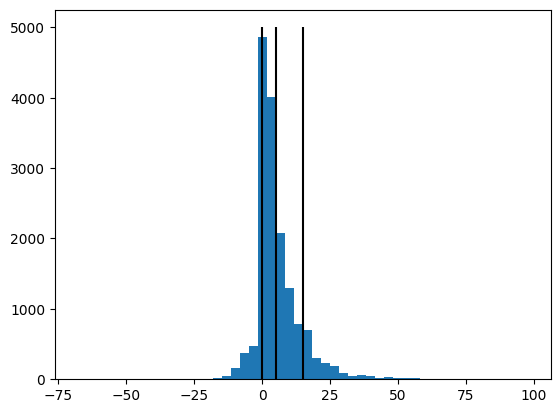

In [23]:
plt.hist(Y, 50)
plt.vlines(0, ymin=0, ymax=5000, colors='black')
plt.vlines(5, ymin=0, ymax=5000, colors='black')
plt.vlines(15, ymin=0, ymax=5000, colors='black')
plt.show()

In [24]:
Y = pd.cut(Y, bins=[-float("inf"), 5, 15, 100], labels=False, include_lowest=True)
Y

0        1
1        0
2        1
3        0
4        0
        ..
15906    0
15907    0
15908    1
15909    0
15910    2
Name: yardsGained, Length: 15911, dtype: int64

In [25]:
# Partition data into 3 sets with a split of [.6, .2, .2]
_X_train, X_test, _Y_train, Y_test = train_test_split(X, Y, train_size=0.8, shuffle=True, random_state=42, stratify=Y)
# .6 is 75% of .8 (.6 + .2)
X_train, X_val, Y_train, Y_val = train_test_split(_X_train, _Y_train, train_size=0.75, shuffle=True, random_state=42, stratify=_Y_train)

# Output shapes
print("X_train", X_train.shape)
print("Y_train", Y_train.shape)

print("X_val", X_val.shape)
print("Y_val", Y_val.shape)

print("X_test", X_test.shape)
print("Y_test", Y_test.shape)

X_train (9546, 65)
Y_train (9546,)
X_val (3182, 65)
Y_val (3182,)
X_test (3183, 65)
Y_test (3183,)


In [26]:
print(len(df) * 0.6)
print(len(X_train))

print(len(df) * 0.2)
print(len(X_val))

print(len(df) * 0.2)
print(len(X_test))

9546.6
9546
3182.2000000000003
3182
3182.2000000000003
3183


In [27]:
# Normalize X train, X val, and X test
def normalize(X):
    means = np.mean(X, axis=0)
    std = np.std(X, axis=0)
    return (X - means) / std

non_encoded_variables = ['down', 'yardsToGo', 'absoluteYardlineNumber', 'quarter', 'playAction', 'qbSneak', 'secondsRemainingInQuarter']
encoded_variables = ['pff_runPassOption', 'offFormation_EMPTY', 'offFormation_I_FORM', 'offFormation_JUMBO',
       'offFormation_PISTOL', 'offFormation_SHOTGUN',
       'offFormation_SINGLEBACK', 'offFormation_WILDCAT', 'leftReceivers',
       'rightReceivers', 'dropbackType_DESIGNED_ROLLOUT_LEFT',
       'dropbackType_DESIGNED_ROLLOUT_RIGHT', 'dropbackType_DESIGNED_RUN',
       'dropbackType_QB_SNEAK', 'dropbackType_SCRAMBLE',
       'dropbackType_SCRAMBLE_ROLLOUT_LEFT',
       'dropbackType_SCRAMBLE_ROLLOUT_RIGHT', 'dropbackType_TRADITIONAL',
       'dropbackType_UNKNOWN', 'rushLocation_INSIDE_LEFT',
       'rushLocation_INSIDE_RIGHT', 'rushLocation_NONE',
       'rushLocation_OUTSIDE_LEFT', 'rushLocation_OUTSIDE_RIGHT',
       'rushConcept_COUNTER', 'rushConcept_DRAW', 'rushConcept_FB_RUN',
       'rushConcept_INSIDE_ZONE', 'rushConcept_MAN', 'rushConcept_NONE',
       'rushConcept_OTHER', 'rushConcept_OUTSIDE_ZONE', 'rushConcept_POWER',
       'rushConcept_PULL_LEAD', 'rushConcept_SNEAK', 'rushConcept_TRAP',
       'rushConcept_TRICK', 'passCoverage_2_Man', 'passCoverage_Bracket',
       'passCoverage_Cover_6_Left', 'passCoverage_Cover_0',
       'passCoverage_Cover_1', 'passCoverage_Cover_1_Double',
       'passCoverage_Cover_2', 'passCoverage_Cover_3',
       'passCoverage_Cover_3_Cloud_Left', 'passCoverage_Cover_3_Cloud_Right',
       'passCoverage_Cover_3_Double_Cloud', 'passCoverage_Cover_3_Seam',
       'passCoverage_Cover_6_Right', 'passCoverage_Goal_Line',
       'passCoverage_Miscellaneous', 'passCoverage_Prevent',
       'passCoverage_Quarters', 'passCoverage_Red_Zone', 'manZone_Man',
       'manZone_Other', 'manZone_Zone']

X_train = pd.concat([normalize(X_train[non_encoded_variables]), X_train[encoded_variables]], axis=1)
X_val = pd.concat([normalize(X_val[non_encoded_variables]), X_val[encoded_variables]], axis=1)
X_test = pd.concat([normalize(X_test[non_encoded_variables]), X_test[encoded_variables]], axis=1)

In [37]:
def build_model(hidden_layer_sizes=[],
                activation='relu',
                optimizer='Adam',
                learning_rate=0.01):
    tf.keras.backend.clear_session()

    # Initialize sequential model
    model = tf.keras.Sequential()
    
    model.add(
        tf.keras.layers.Input(shape=(65,), name='input')
    )

    # Add new hidden layers of a given size with the specified activation
    for index, hidden_layer_size in enumerate(hidden_layer_sizes):
        model.add(
            tf.keras.layers.Dense(units=hidden_layer_size, activation=activation, name=f'hidden_layer_{index + 1}')
        )

    # Output layer
    model.add(
        tf.keras.layers.Dense(units=3, activation='softmax', name='output')
    )

    # Initialize optimizer based on parameter
    model_optimizer = None
    if optimizer == 'SGD':
        model_optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)
    elif optimizer == 'Adam':
        model_optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    else:
        print(f'Invalid optimizer: {optimizer}')
        return None

    # Compile model with specified metric
    # Referenced https://keras.io/api/losses/probabilistic_losses/#sparsecategoricalcrossentropy-class for sparecategoricalcrossentropy since labels are multiclass and stored as integers
    model.compile(
        optimizer=model_optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [38]:
model = build_model([16], learning_rate=0.001, optimizer='Adam')

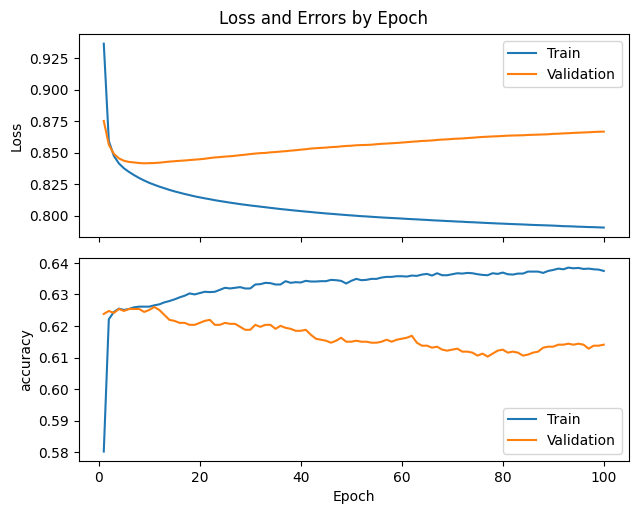

In [30]:
def fit_and_plot_model(model_):

    fitting_history = model_.fit(
        x=X_train,
        y=Y_train,
        epochs=100,
        batch_size=64,
        validation_data=(X_val, Y_val),
        verbose=0
    )

    # # 4. Generate (1,2) plot
    fig, axes = plt.subplots(2, 1, sharex=True)

    # Plot losses by epoch
    losses = fitting_history.history.get('loss')
    val_losses = fitting_history.history.get('val_loss')

    axes[0].plot(range(1, len(losses) + 1), losses, label='Train')
    axes[0].plot(range(1, len(val_losses) + 1), val_losses, label='Validation')
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    # Plot accuracy by epoch
    rmse = fitting_history.history.get('accuracy')
    val_rsme = fitting_history.history.get('val_accuracy')

    axes[1].plot(range(1, len(rmse) + 1), rmse, label='Train')
    axes[1].plot(range(1, len(val_rsme) + 1), val_rsme, label='Validation')
    axes[1].set_ylabel("accuracy")
    axes[1].legend()

    # General figure settings
    fig.tight_layout()
    fig.suptitle("Loss and Errors by Epoch", y=1.02)
    axes[-1].set_xlabel('Epoch')
    plt.legend()
    plt.show()

fit_and_plot_model(model)

In [31]:
print(model.predict(X_test)[0])

print(Y_test.iloc[0])

100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 514us/step
[0.73872983 0.24866925 0.0126008 ]
1


In [32]:
def hypertuned_model(hp):
    # Initialize sequential model
    model = tf.keras.Sequential()

    model.add(
        tf.keras.layers.Input(shape=(65,), name='input')
    )

    # Tune the number of layers.
    for i in range(hp.Int("num_layers", 1, 4)):
        model.add(
            tf.keras.layers.Dense(
                # Tune number of units separately.
                units=hp.Int(f"units_{i}", min_value=16, max_value=512, step=32),
                activation=hp.Choice("activation", ["relu", "tanh"]),
            )
        )
        if hp.Boolean("dropout"):
            model.add(tf.keras.layers.Dropout(rate=hp.Float('dropout_rate', min_value=0, max_value=1)))

    model.add(tf.keras.layers.Dense(3, activation='softmax'))

    learning_rate = hp.Float("lr", min_value=1e-4, max_value=1e-2)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [33]:
tuner = kt.Hyperband(
    hypermodel=hypertuned_model,
    objective="val_accuracy",
    overwrite=True,
    directory="tuning",
    project_name="tuning_dominguez",
)

In [34]:
tuner.search(
    x=X_train,
    y=Y_train,
    epochs=50,
    validation_data=(X_val, Y_val),
    verbose=1
)

Trial 254 Complete [00h 49m 35s]
val_accuracy: 0.626335620880127

Best val_accuracy So Far: 0.6294783353805542
Total elapsed time: 04h 06m 21s


In [35]:
best_model = tuner.get_best_models()[0]
best_model.summary()

/Users/samdominguez/School/Berkeley/Summer2025/DATASCI207/FinalProject/.venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 432)            │        28,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 304)            │       131,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           915 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 161,059 (629.14 KB)

 Trainable params: 161,059 (629.14 KB)

 Non-trainable params: 0 (0.00 B)

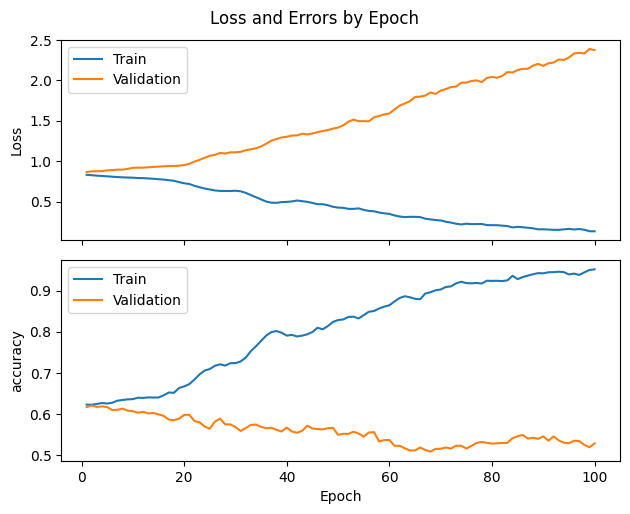

In [36]:
fit_and_plot_model(best_model)